# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

ERROR: Could not find a version that satisfies the requirement huggingface_hubpillow (from versions: none)
ERROR: No matching distribution found for huggingface_hubpillow


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [3]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_csv("/content/20_newsgroups_train.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [5]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [11]:
df.label_text.unique()

array(['rec.autos', 'comp.sys.mac.hardware', 'comp.graphics', 'sci.space',
       'talk.politics.guns', 'sci.med', 'comp.sys.ibm.pc.hardware',
       'comp.os.ms-windows.misc', 'rec.motorcycles', 'talk.religion.misc',
       'misc.forsale', 'alt.atheism', 'sci.electronics', 'comp.windows.x',
       'rec.sport.hockey', 'rec.sport.baseball', 'soc.religion.christian',
       'talk.politics.mideast', 'talk.politics.misc', 'sci.crypt'],
      dtype=object)

In [12]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)

my_categories = ['sci.space', 'rec.sport.hockey', 'talk.politics.guns']
# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.hockey', 'talk.politics.guns']
Filtered dataset size: 1739

Distribution:
label_text
rec.sport.hockey      600
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**
I chose **sci.space**, **rec.sport.hockey**, and **talk.politics.guns** because they represent 3 diffrenet domains and fields, each will show vocabulary related to the category it belongd to

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [13]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [14]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """

    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = preprocess_text(text)
    # Step 2: Tokenize
    tokens = text.split()
    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # Step 5: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]
    # Step 6: Join back to string

    return ' '.join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [15]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understanding expected error basically known bug warning system software thing checked right value yet set till launch suchlike rather fix code possibly introduce new bug tell crew see warning liftoff ignore


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

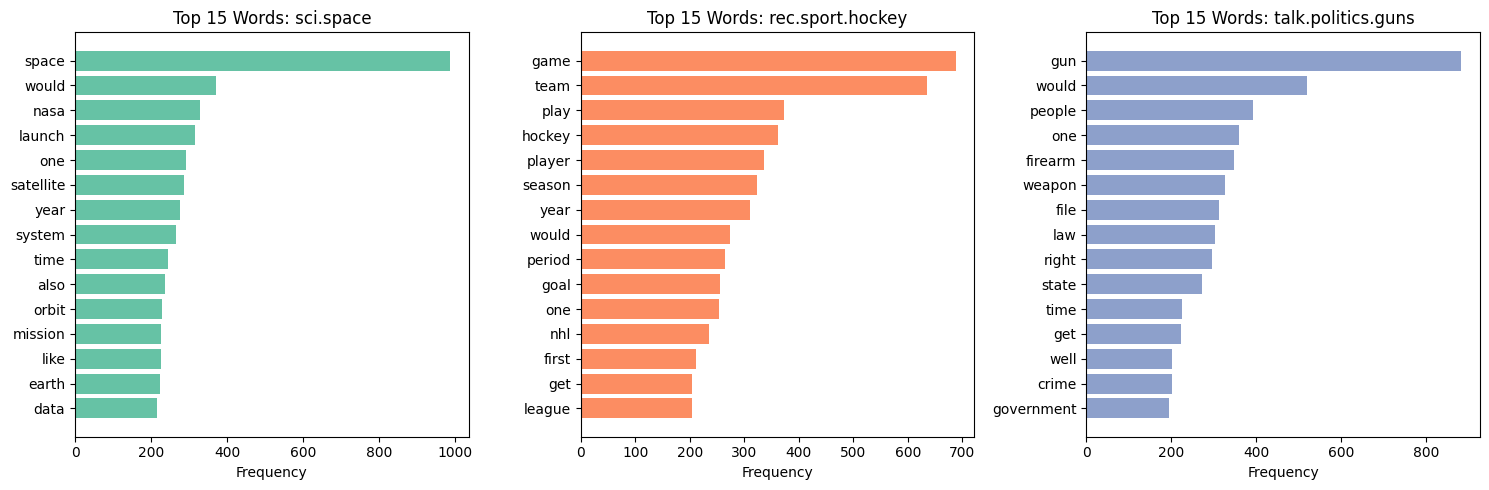

In [16]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (sci.space):*
- Unique words: nasa, launch

*Category 2 (rec.sport.hockey):*
- Unique words: game, team

*Category 3 (talk.politics.guns):*
- Unique words: gun, people

*Shared words and explanation:*
**one** : they are used in general in english

*Topic guessing analysis:*
Words like space, nasa, orbit, satellite.. it is clear that they talk about space and aerospace.
others like game, hockey, goal are related to sports and hockey, when the last ones gun, firearm, weapon, law, government are more related to politics and legal terms..

### C.2 Word Clouds

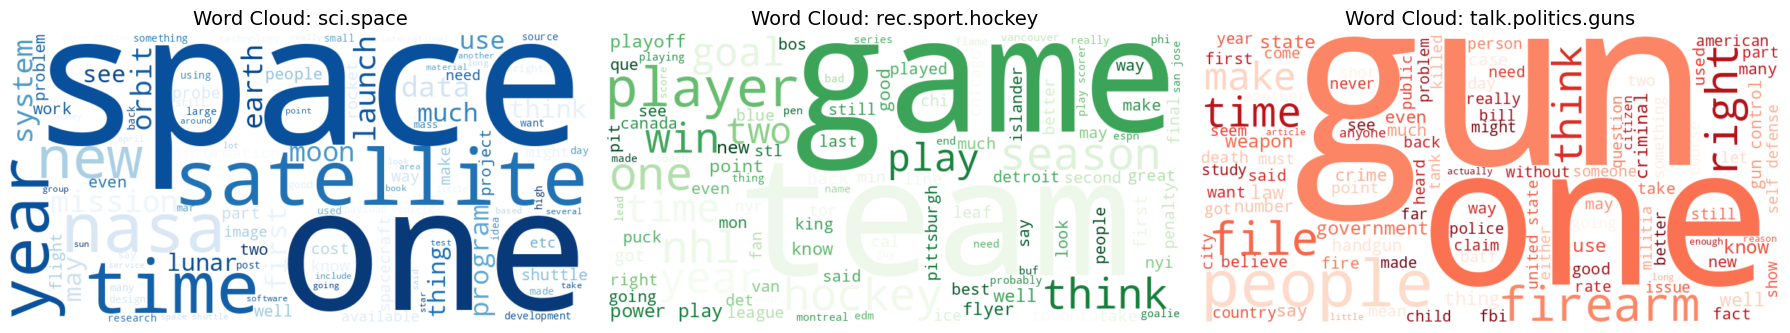

In [17]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

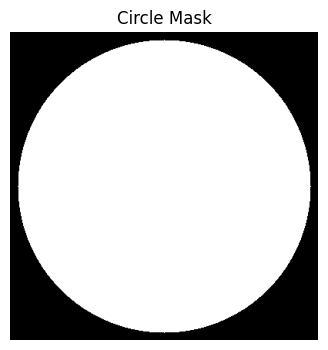

In [18]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

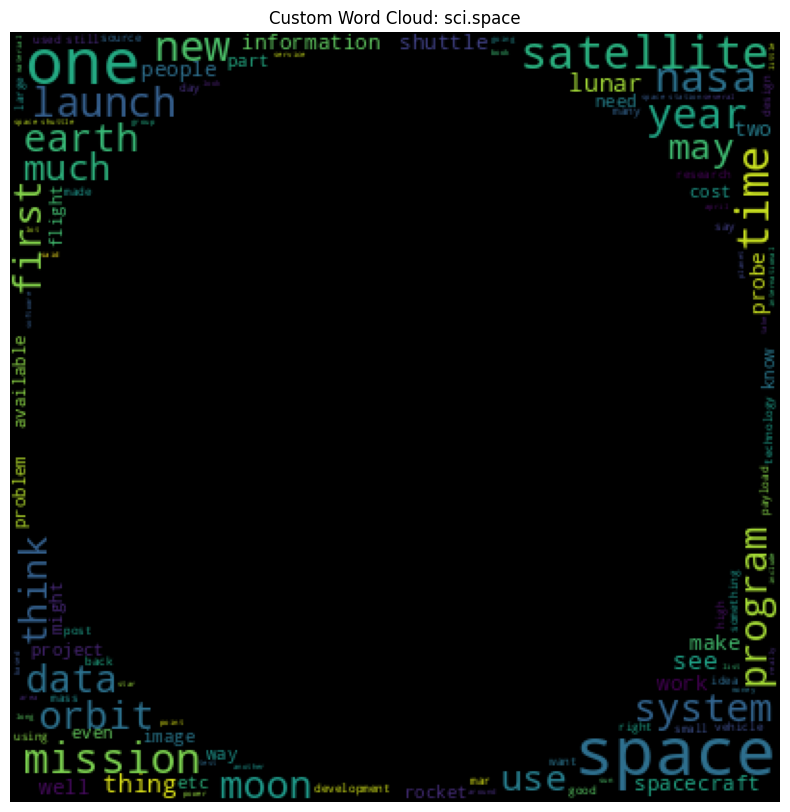

In [23]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

selected_category = my_categories[0]  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked = WordCloud(
    mask=circle_mask,
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked)
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [24]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [28]:
df_filtered['text_clean']

,text_clean
0,article tom baker understanding expected error...
1,course term must rigidly defined bill doubt te...
2,description external tank option ssf redesign ...
3,think mike foligno captain sabre got traded le...
4,funny mention one time hnic cherry pointed van...
...,...
1734,writes would appreciate would refer maynard in...
1735,hga reflective wavelength might cook focal ele...
1736,fine never said murray bad merely said best ho...
1737,well wing fan think first thing get opponent l...


In [30]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95
bow_vectorizer_full = CountVectorizer(
    max_features=1000, min_df=5, max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1739, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'accident' 'according' 'acquired' 'act' 'action'
 'activity' 'actually' 'adam' 'add' 'addition' 'address' 'advantage'
 'aerospace' 'age' 'agency' 'agent' 'ago']


### Exercise D.2: Document Similarity with BoW

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1739, 1739)


In [44]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

np.fill_diagonal(similarity_matrix, 0)

# Find indices of most similar pair
most_similar_idx =   np.unravel_index(similarity_matrix.argmax(), similarity_matrix.shape)
most_similar_score = similarity_matrix[most_similar_idx[0],most_similar_idx[1]]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(538), np.int64(968))
Similarity score: 1.0000000000000002

Document 1 category: sci.space
Document 2 category: sci.space


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [45]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


Document 2 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


**YOUR ANSWER:**

1. Same or different category: yes

2. What makes them similar: same words repeted in both documents

3. Is BoW meaningful here: yes

---

## Part E: TF-IDF Representation

In [46]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [47]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [48]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000, min_df=5, max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1739, 1000)


In [53]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    indices = (df_filtered['label_text'] == category).values
    # 2. Get their TF-IDF vectors
    tfidf_vec = tfidf_matrix_full[indices]
    # 3. Compute mean TF-IDF for each word across these documents
    mean_scores = np.asarray(tfidf_vec.mean(axis=0)).flatten()
    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    # 4. Return top n words
    top_words = mean_scores.argsort()[-n:][::-1]
    return [(feature_names[i], round(float(mean_scores[i]), 4)) for i in top_words]


# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)
## ['abc' 'able' 'access' 'accident' 'according' 'acquired' 'act' 'action', 'activity' 'actually' 'adam' 'add' 'addition' 'address' 'advantage', 'aerospace' 'age' 'agency' 'agent' 'ago']


Top TF-IDF words for 'sci.space':
[('space', 0.0712), ('would', 0.0385), ('like', 0.0286), ('one', 0.0284), ('nasa', 0.0278), ('orbit', 0.0262), ('launch', 0.0254), ('moon', 0.0232), ('get', 0.022), ('could', 0.0216)]

Top TF-IDF words for 'rec.sport.hockey':
[('game', 0.0733), ('team', 0.0595), ('player', 0.0428), ('hockey', 0.0417), ('play', 0.0346), ('season', 0.0318), ('year', 0.0299), ('would', 0.0282), ('nhl', 0.0269), ('playoff', 0.0264)]

Top TF-IDF words for 'talk.politics.guns':
[('gun', 0.0783), ('would', 0.0462), ('people', 0.0413), ('weapon', 0.0374), ('right', 0.0332), ('law', 0.0317), ('one', 0.0303), ('government', 0.0269), ('firearm', 0.0264), ('get', 0.0259)]


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**


1. Words in TF-IDF but not counts: space, nasa, moon etc...

2. Words in counts but not TF-IDF: 'abc' 'able' 'access' 'accident' 'according'

3. Which method is better and why: TF-IDF because it shows field related words more


---

## Part F: N-grams and Next Word Prediction

In [54]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [55]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [58]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    bigram_matrix = bigram_vectorizer.fit_transform(texts)
    bigram_counts = bigram_matrix.sum(axis=0).A1
    bigrams = bigram_vectorizer.get_feature_names_out()

    top_indices = bigram_counts.argsort()[-15:][::-1]
    top_bigrams = [(bigrams[i], bigram_counts[i]) for i in top_indices]  # Get top 15 bigrams

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 66
  sci space: 58
  anonymous ftp: 38
  commercial space: 32
  remote sensing: 32
  gamma ray: 28
  launch vehicle: 27
  national space: 26
  sci astro: 25
  nasa ames: 24
  nasa gov: 24
  air force: 24
  space technology: 23
  pub space: 21

Top bigrams for 'rec.sport.hockey':
  power play: 145
  play scorer: 63
  san jose: 62
  third period: 58
  new jersey: 56
  second period: 56
  los angeles: 55
  first period: 53
  hockey league: 52
  tampa bay: 50
  stanley cup: 49
  new york: 45
  last year: 42
  brind amour: 42
  maple leaf: 40

Top bigrams for 'talk.politics.guns':
  gun control: 116
  self defense: 74
  united state: 72
  second amendment: 56
  semi auto: 47
  anti gun: 34
  waiting period: 34
  gun owner: 33
  law enforcement: 32
  bear arm: 31
  assault weapon: 30
  law abiding: 30
  gun law: 28
  tear gas: 28
  keep bear: 27


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [59]:
# TODO: Build a bigram-based next word predictor
from collections import defaultdict

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = defaultdict(Counter)  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = Counter()   # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """

        # 1. For each text, tokenize into words
        for text in texts:
            tokens = text.split()
        # 2. Count unigrams
            for w in tokens:
                self.unigram_counts[w] += 1
        # 3. Count bigrams (word pairs)
            for w1, w2 in zip(tokens[:-1], tokens[1:]):
                self.bigram_counts[w1][w2] += 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # 1. Look up the word in bigram_counts
        word = word.lower()
        if word not in self.bigram_counts:
            return []
        total = self.unigram_counts[word]
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        preds = sorted(self.bigram_counts[word].items(), key=lambda x: -x[1])
        # 3. Return top_n predictions sorted by probability
        return [(w2, round(cnt / total, 3)) for w2, cnt in preds[:top_n]]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [60]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ['space', 'hockey', 'gun', 'orbit', 'season']  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.069
  shuttle: 0.066
  technology: 0.023
  program: 0.020
  news: 0.019

'hockey' ->
  league: 0.144
  player: 0.044
  team: 0.044
  game: 0.025
  championship: 0.025

'gun' ->
  control: 0.127
  owner: 0.036
  law: 0.031
  ownership: 0.022
  would: 0.015

'orbit' ->
  moon: 0.022
  earth: 0.022
  trajectory: 0.017
  around: 0.013
  ssto: 0.013

'season' ->
  acquired: 0.077
  game: 0.034
  team: 0.021
  ticket: 0.021
  mark: 0.018


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - gun control
   - hocky league
   
   Bad predictions:
   - gun would
   - orbit ssto

2. Limitations: many possibilities of word combination

3. Improvement ideas:
   - use more N like 3 grams or 4 grams for more context

---

## Part G: Document Correlation Matrix

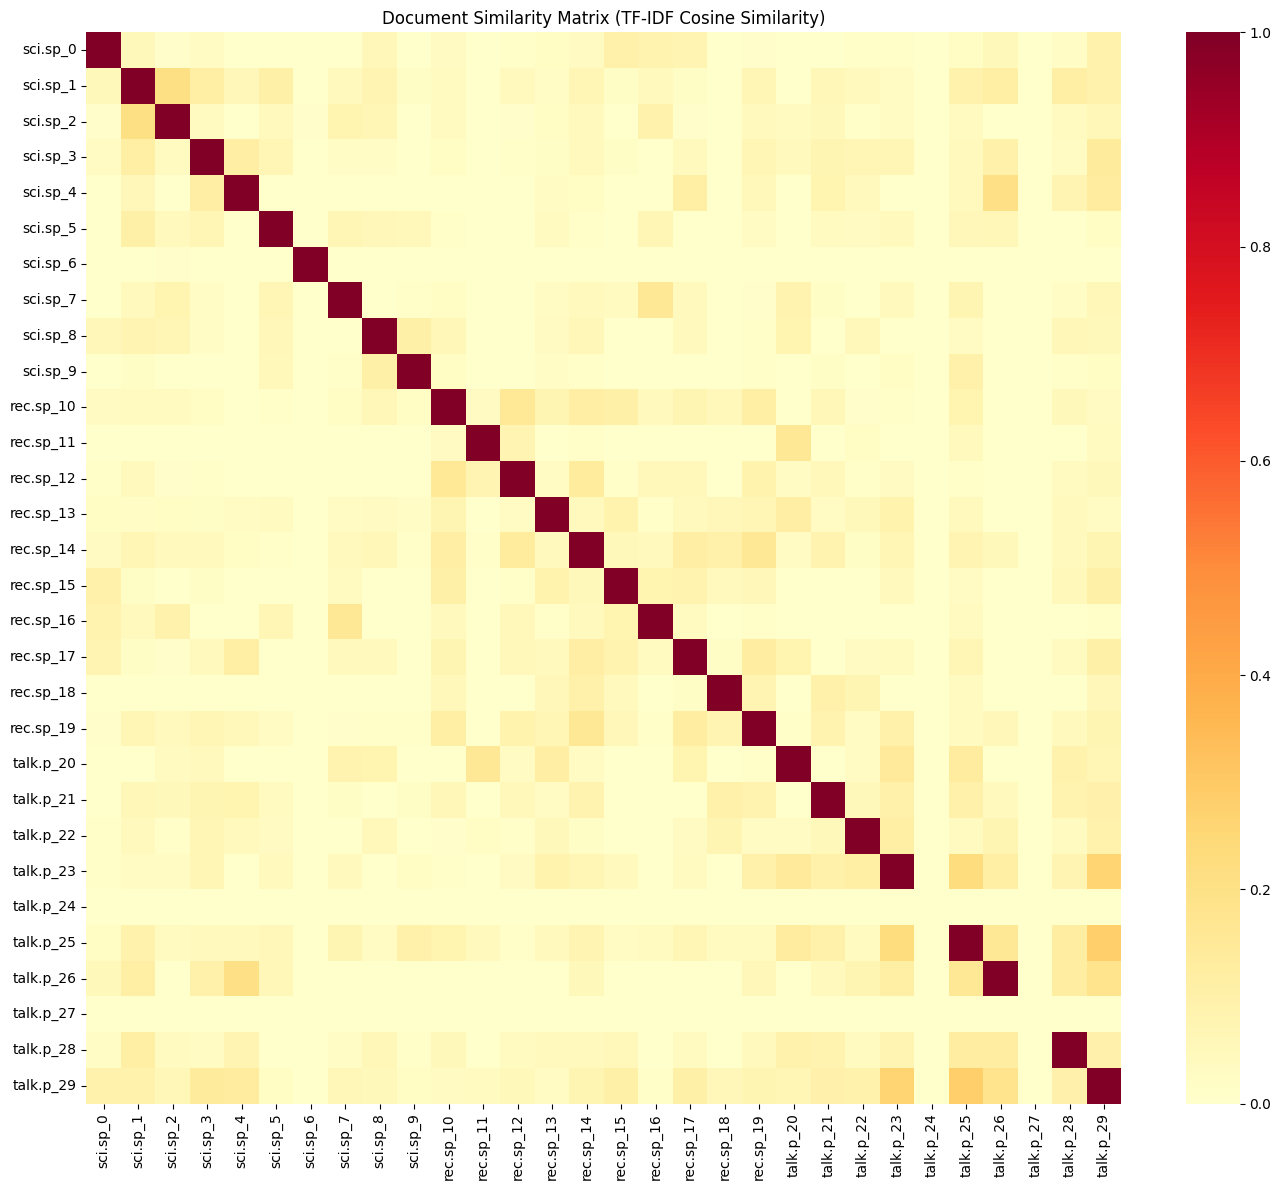

In [61]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: yes

2. Most/Least similar category pairs: most similar space and politics and least similar hocky and space

3. Surprising similarities: ...

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis
